In [1]:
import random
from tqdm import tqdm
from collections import defaultdict
def get_available_nodes(graph, source, hop=1):
    if hop == 0:
        return set(graph.keys()) - {source}
    current = {source}
    visited = {source}
    available_nodes = set()
    for _ in range(hop):
        next_level = set()
        for node in current:
            neighbors = graph[node]
            available_nodes.update(neighbors)
            for neighbor in neighbors:
                if neighbor not in visited:
                    visited.add(neighbor)
                    next_level.add(neighbor)
        current = next_level
        if not current:
            break
    available_nodes.discard(source)
    return available_nodes

def simulate(graph, victim, originator, available_nodes, p=1):
    if originator not in available_nodes:
        raise ValueError("Originator not in victim neighborhood")
    victim_neighbors = graph[victim]
    remaining = set(victim_neighbors)  # not yet infected
    current = {originator}
    visited = {originator}
    time = 0
    spread_time = 0
    if originator in remaining:
        remaining.remove(originator)

    while current and remaining:
        next_level = set()
        for node in current:
            neighbors = available_nodes & graph[node]
            for neighbor in neighbors:
                if neighbor not in visited and random.random() <= p:
                    visited.add(neighbor)
                    next_level.add(neighbor)
                    if neighbor in remaining:
                        remaining.remove(neighbor)
                        spread_time = time + 1  # last infection time updates
        current = next_level
        time += 1
    victim_degree = len(victim_neighbors)
    infected = victim_neighbors - remaining
    spread_factor = len(infected) / victim_degree if victim_degree > 0 else 0

    return spread_time, spread_factor

def run_simulation_by_k(graph, hop=1, p=1):
    data_by_k = defaultdict(lambda: defaultdict(list))
    for victim, victim_node in graph.items():
        available_nodes = get_available_nodes(graph, victim, hop=hop)
        for originator in victim_node:
            data = simulate(graph, victim, originator, available_nodes, p)
            spread_time, spread_factor = data[0], data[1]
            k = len(victim_node)
            data_by_k[k]["spread_time"].append(spread_time)
            data_by_k[k]["spread_factor"].append(spread_factor)
    return data_by_k

In [2]:
import pickle
import os
def load_graphs(path):
    with open(path, "rb") as f:
        data = pickle.load(f)
    return data

def save_results(results, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "wb") as f:
        pickle.dump(results, f)

def to_dict(obj):
    if isinstance(obj, defaultdict):
        return {k: to_dict(v) for k, v in obj.items()}
    return obj

In [3]:
size = 10
for p in range(20):
    if not os.path.exists(f"fig_data/fig07/fig07_p{p:02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        small_world_path = f"data/small_world/sw_network_p{p:02d}_N{size:03d}K.pkl"
        sw_graphs = load_graphs(small_world_path)
        print(f"Running simulation for p={p:02d}:")
        for graph in tqdm(sw_graphs):
            graph_result = run_simulation_by_k(graph)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del sw_graphs
        save_results(result, f"fig_data/fig07/fig07_p{p:02d}.pkl")
        del result

In [4]:
size = 1
for p in range(3):
    if not os.path.exists(f"fig_data/fig07/fig07_random_p{p:02d}.pkl"):
        result = defaultdict(lambda: defaultdict(list))
        random_path = f"data/random/random_network_p{p:02d}_N{size:03d}K.pkl"
        random_graphs = load_graphs(random_path)
        print(f"Running simulation for p={p:02d}:")
        for graph in tqdm(random_graphs):
            graph_result = run_simulation_by_k(graph)
            for k, metrics in graph_result.items():
                for metric, values in metrics.items():
                    result[k][metric].extend(values)
        result = to_dict(result)
        del random_graphs
        save_results(result, f"fig_data/fig07/fig07_random_p{p:02d}.pkl")
        del result

In [5]:
import networkx as nx

def compute_graph_metrics(graph):
    G = nx.Graph(graph)
    C = nx.average_clustering(G)
    L = nx.average_shortest_path_length(G)
    return C, L

In [6]:
for p in range(20):
    out_path = f"fig_data/fig07/fig07_p{p:02d}_CL.pkl"
    if not os.path.exists(out_path):
        raise FileNotFoundError(f"Graph data for p={p:02d} not found.")

In [7]:
def generate_small_world_network(num_nodes, k, p):
    graph = {i: set() for i in range(num_nodes)}

    # Initial ring lattice
    for i in range(num_nodes):
        for j in range(1, k // 2 + 1):
            neighbor = (i + j) % num_nodes
            graph[i].add(neighbor)
            graph[neighbor].add(i)
    nodes = list(range(num_nodes))

    # Rewire
    for i in range(num_nodes):
        for j in range(1, k // 2 + 1):
            if random.random() > p:
                continue
            old_neighbor = (i + j) % num_nodes
            # Remove old edge
            graph[i].discard(old_neighbor)
            graph[old_neighbor].discard(i)
            # Avoid self-loops and duplicate edges
            forbidden = set(graph[i])
            forbidden.add(i)

            while True:
                new_neighbor = random.choice(nodes)
                if new_neighbor not in forbidden:
                    break

            graph[i].add(new_neighbor)
            graph[new_neighbor].add(i)
    return graph

graph0 = generate_small_world_network(num_nodes=10000, k=4, p=-1)
C0, L0 = compute_graph_metrics(graph0)
print(f"C0={C0:.4f}, L0={L0:.4f}")

C0=0.5000, L0=1250.3750


100%|██████████| 20/20 [00:00<00:00, 864.60it/s]


Fig 7a


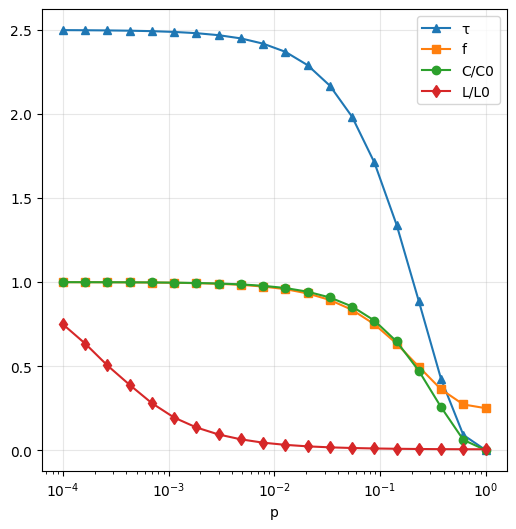

In [8]:
import matplotlib.pyplot as plt
import numpy as np

#Spread time
plt.figure(figsize=(6, 6))
sw_data_by_p = {
    "spread_time": defaultdict(list),
    "spread_factor": defaultdict(list),
    "clustering": defaultdict(list),
    "path_length": defaultdict(list)
}
for p in tqdm(range(20)):
    sw_data_by_k = load_graphs(f"fig_data/fig07/fig07_p{p:02d}.pkl")
    for k in sw_data_by_k:
        sw_data_by_p["spread_time"][p].extend(sw_data_by_k[k]["spread_time"])
        sw_data_by_p["spread_factor"][p].extend(sw_data_by_k[k]["spread_factor"])
del sw_data_by_k

for p in tqdm(range(20)):
    sw_data_CL = load_graphs(f"fig_data/fig07/fig07_p{p:02d}_CL.pkl")
    sw_data_by_p["clustering"][p].extend(sw_data_CL["C"])
    sw_data_by_p["path_length"][p].extend(sw_data_CL["L"])
del sw_data_CL

p_range = np.logspace(-4, 0, 20).tolist()
sw_plot_data_by_p = {p: sum(times) / len(times) for p, times in sw_data_by_p["spread_time"].items()}
plt.plot(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="τ", marker = "^")

sw_plot_data_by_p = {p: sum(factor) / len(factor) for p, factor in sw_data_by_p["spread_factor"].items()}
plt.plot(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="f", marker = "s")

sw_plot_data_by_p = {p: (sum(C) / len(C)) / C0 for p, C in sw_data_by_p["clustering"].items()}
plt.plot(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="C/C0", marker = "o")

sw_plot_data_by_p = {p: (sum(L) / len(L)) / L0 for p, L in sw_data_by_p["path_length"].items()}
plt.plot(p_range, [sw_plot_data_by_p[p_range.index(p)] for p in p_range], label="L/L0", marker = "d")
del sw_data_by_p, sw_plot_data_by_p

print("Fig 7a")
plt.xscale("log")
plt.xlabel("p")
#plt.ylabel("τ")
#plt.title("Average spread time τ vs degree k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

100%|██████████| 3/3 [00:04<00:00,  1.52s/it]


Fig 7b


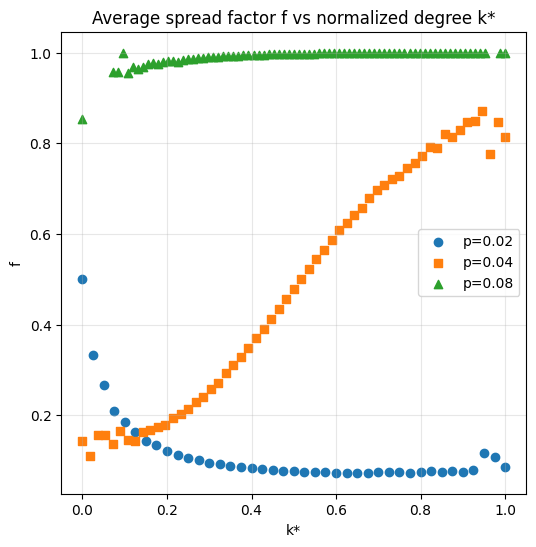

In [9]:
#Spread factor
markers = ["o", "s", "^", "d"]
ps = [0.02, 0.04, 0.08]

plt.figure(figsize=(6, 6))
sw_data_by_p = defaultdict(lambda: defaultdict(list))
for p in tqdm(range(3)):
    sw_data_by_k = load_graphs(f"fig_data/fig07/fig07_random_p{p:02d}.pkl")
    max_k = max(sw_data_by_k.keys())
    min_k = min(sw_data_by_k.keys())
    for k in sw_data_by_k:
        sw_data_by_p[p][(k-min_k)/(max_k-min_k)].extend(sw_data_by_k[k]["spread_factor"])
del sw_data_by_k

for p in range(3):
    ks = sorted(sw_data_by_p[p].keys())
    spread_factors = [sum(sw_data_by_p[p][k]) / len(sw_data_by_p[p][k]) for k in ks]
    plt.scatter(ks, spread_factors, label=f"p={ps[p]:.2f}", marker = markers[p])
del sw_data_by_p

print("Fig 7b")
plt.xlabel("k*")
plt.ylabel("f")
plt.title("Average spread factor f vs normalized degree k*")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

100%|██████████| 3/3 [00:04<00:00,  1.42s/it]


Fig 7b inset


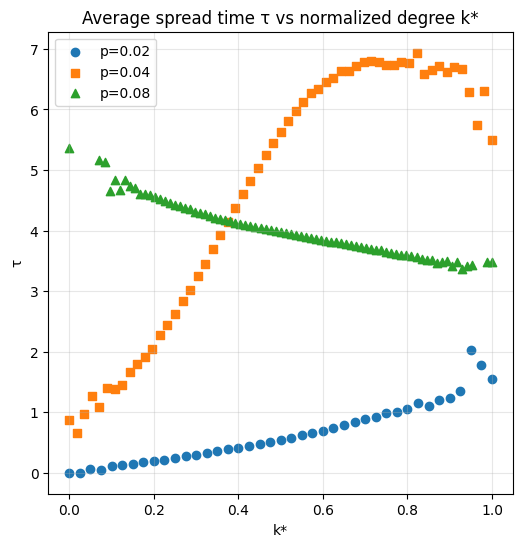

In [10]:
#Spread time
markers = ["o", "s", "^", "d"]
ps = [0.02, 0.04, 0.08]

plt.figure(figsize=(6, 6))
sw_data_by_p = defaultdict(lambda: defaultdict(list))
for p in tqdm(range(3)):
    sw_data_by_k = load_graphs(f"fig_data/fig07/fig07_random_p{p:02d}.pkl")
    max_k = max(sw_data_by_k.keys())
    min_k = min(sw_data_by_k.keys())
    for k in sw_data_by_k:
        sw_data_by_p[p][(k-min_k)/(max_k-min_k)].extend(sw_data_by_k[k]["spread_time"])
del sw_data_by_k

for p in range(3):
    ks = sorted(sw_data_by_p[p].keys())
    spread_times = [sum(sw_data_by_p[p][k]) / len(sw_data_by_p[p][k]) for k in ks]
    plt.scatter(ks, spread_times, label=f"p={ps[p]:.2f}", marker = markers[p])
del sw_data_by_p

print("Fig 7b inset")
plt.xlabel("k*")
plt.ylabel("τ")
plt.title("Average spread time τ vs normalized degree k*")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()